# Adversarial Search: Playing Connect 4

Student Name: [Derek Brown]

I have used the following AI tools: [Copilot, Claude]

I understand that my submission needs to be my own work: [DB]

## Learning Outcomes

* Implement adversarial search algorithms for strategic game play.
* Analyze and optimize search in complex game spaces.
* Design effective heuristic evaluation functions.
* Compare performance across different agent strategies.
* Evaluate algorithmic trade-offs between decision quality and efficiency.

## Instructions

Total Points: Undergraduates 100, graduate students 110

Complete this notebook and submit it. The notebook needs to be a complete project report with your implementation, documentation including a short discussion of how your implementation works and your design choices, and experimental results (e.g., tables and charts with simulation results) with a short discussion of what they mean. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook as a HTML file.


## Introduction

You will implement different versions of agents that play Connect 4:

> "Connect 4 is a two-player connection board game, in which the players choose a color and then take turns dropping colored discs into a seven-column, six-row vertically suspended grid. The pieces fall straight down, occupying the lowest available space within the column. The objective of the game is to be the first to form a horizontal, vertical, or diagonal line of four of one's own discs." (see [Connect Four on Wikipedia](https://en.wikipedia.org/wiki/Connect_Four))

Note that [Connect-4 has been solved](https://en.wikipedia.org/wiki/Connect_Four#Mathematical_solution)
in 1988. A connect-4 solver with a discussion of how to solve different parts of the problem can be found here: https://connect4.gamesolver.org/en/

## Task 1: Defining the Search Problem [10 point]

Define the components of the search problem:

* Initial state
* Actions
* Transition model (result function)
* Goal state (terminal state and utility)

Describe each component and then implement it as a function that can be used by search algorithms.

In [60]:
# Your code/answer goes here.
import numpy as np

# ─── Board Constants ───────────────────────────────────────────────────────────
ROWS    = 6
COLS    = 7
EMPTY   = 0
P1      = 1   # Maximizing player
P2      = 2   # Minimizing player

# ══════════════════════════════════════════════════════════════════════════════
# TASK 1 — Defining the Search Problem
# ══════════════════════════════════════════════════════════════════════════════

# ─── Initial State ─────────────────────────────────────────────────────────────
# The initial state is an empty 6×7 board with Player 1 to move.
# We represent the board as a 2D NumPy array (row 0 = top, row 5 = bottom).
# The current player is stored alongside the board.

def initial_state():
    """
    Returns the starting state of the game:
      - A 6×7 board filled with EMPTY (0)
      - Player 1 moves first
    """
    board = np.zeros((ROWS, COLS), dtype=int)
    current_player = P1
    return board, current_player


# ─── Actions ───────────────────────────────────────────────────────────────────
# An action is a column index (0–6) into which the current player drops a disc.
# A column is a valid action only if it is not yet full (top cell is EMPTY).

def actions(board):
    """
    Returns a list of valid column indices (actions) for the current state.
    A column is valid if its top row is still empty.
    """
    return [col for col in range(COLS) if board[0][col] == EMPTY]


# ─── Transition Model (result function) ────────────────────────────────────────
# Dropping a disc into a column causes it to fall to the lowest empty row.
# The result is a new board state with the disc placed and the turn switched.

def result(board, action, current_player):
    """
    Applies `action` (a column index) for `current_player` and returns
    (new_board, next_player).

    The disc falls to the lowest empty row in the chosen column.
    Raises ValueError if the column is full (invalid action).
    """
    if board[0][action] != EMPTY:
        raise ValueError(f"Column {action} is full — invalid action.")

    new_board = board.copy()

    # Find the lowest empty row in this column (gravity)
    for row in range(ROWS - 1, -1, -1):
        if new_board[row][action] == EMPTY:
            new_board[row][action] = current_player
            break

    next_player = P2 if current_player == P1 else P1
    return new_board, next_player


# ─── Goal State / Terminal State + Utility ─────────────────────────────────────
# The game ends when:
#   (a) A player connects four discs in a row (horizontally, vertically, or
#       diagonally) → that player wins.
#   (b) The board is completely full with no winner → draw.
#
# Utility (from P1's perspective):
#   +1  →  P1 wins
#   -1  →  P2 wins
#    0  →  draw

def _check_winner(board, player):
    """Returns True if `player` has four in a row anywhere on the board."""
    # Horizontal
    for r in range(ROWS):
        for c in range(COLS - 3):
            if all(board[r][c + i] == player for i in range(4)):
                return True
    # Vertical
    for r in range(ROWS - 3):
        for c in range(COLS):
            if all(board[r + i][c] == player for i in range(4)):
                return True
    # Diagonal (↘)
    for r in range(ROWS - 3):
        for c in range(COLS - 3):
            if all(board[r + i][c + i] == player for i in range(4)):
                return True
    # Diagonal (↙)
    for r in range(ROWS - 3):
        for c in range(3, COLS):
            if all(board[r + i][c - i] == player for i in range(4)):
                return True
    return False


def is_terminal(board):
    """
    Returns True if the game is over:
      - P1 or P2 has four in a row, OR
      - The board is completely full (draw).
    """
    return (
        _check_winner(board, P1)
        or _check_winner(board, P2)
        or len(actions(board)) == 0
    )


def utility(board):
    """
    Returns the utility of a terminal state from P1's perspective:
      +1  →  P1 wins
      -1  →  P2 wins
       0  →  draw
    Should only be called on terminal states.
    """
    if _check_winner(board, P1):
        return 1
    if _check_winner(board, P2):
        return -1
    return 0  # Draw


# ─── Quick sanity check ────────────────────────────────────────────────────────
if __name__ == "__main__":
    board, player = initial_state()
    print("Initial board:\n", board)
    print("Valid actions:", actions(board))

    board, player = result(board, 3, player)   # P1 drops in col 3
    board, player = result(board, 3, player)   # P2 drops in col 3
    print("\nAfter two moves (both col 3):\n", board)
    print("Terminal?", is_terminal(board))
    print("Current player to move:", player)

Initial board:
 [[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]
Valid actions: [0, 1, 2, 3, 4, 5, 6]

After two moves (both col 3):
 [[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 2 0 0 0]
 [0 0 0 1 0 0 0]]
Terminal? False
Current player to move: 1


How big is the state space? Give an estimate and explain it.

In [61]:
# Your answer goes here.
# ─── State Space Estimate ──────────────────────────────────────────────────────
#
# The board has 6 × 7 = 42 cells.
# Each cell can be in one of 3 states: EMPTY, P1, or P2.
#
# Naive upper bound (treating every combination as possible):
#   3^42 ≈ 1.09 × 10^20
#
# However, most of those combinations are physically impossible because:
#   1. Pieces must obey gravity — a disc can't float above an empty cell.
#   2. The number of P1 and P2 discs can differ by at most 1 (turns alternate).
#   3. The game ends as soon as someone wins — states after a win are invalid.
#
# Taking these constraints into account, the true number of reachable, valid
# board positions has been computed to be approximately:
#   ~4.5 × 10^12  (about 4.5 trillion)
#
# This is still enormous, which is exactly why we need heuristic search
# (alpha-beta pruning + evaluation functions) instead of brute force.

print("Naive upper bound:  3^42 =", 3**42, f"≈ {3**42:.2e}")
print("Realistic estimate: ~4.5 × 10^12 valid positions")

Naive upper bound:  3^42 = 109418989131512359209 ≈ 1.09e+20
Realistic estimate: ~4.5 × 10^12 valid positions


How big is the game tree that minimax search will go through? Give an estimate and explain it.

In [62]:
# Your answer goes here.
# ─── Game Tree Size Estimate ───────────────────────────────────────────────────
#
# The game tree is different from the state space — it counts paths (sequences
# of moves), not unique board positions, so the same board can appear many times.
#
# Key numbers:
#   - Maximum game length: 42 moves (6 rows × 7 cols, board fully filled)
#   - Average game length: ~36 moves (most games end before the board fills)
#   - Branching factor: starts at 7 (all columns open), shrinks as columns fill
#   - Average effective branching factor: ~4 (accounting for columns filling
#     up and games ending early)
#
# Very rough upper bound (7 choices every move for 42 moves):
#   7^42 ≈ 3.1 × 10^35  nodes  ← way too large to search completely
#
# More realistic estimate using average branching factor b ≈ 4, depth d ≈ 36:
#   4^36 ≈ 4.7 × 10^21  nodes  ← still enormous
#
# This confirms that plain minimax (without pruning) is completely infeasible.
# With alpha-beta pruning and a good move ordering, the effective branching
# factor drops to roughly √4 ≈ 2, making practical search depths of 10–15
# moves achievable within a reasonable time budget.

import math

naive_upper  = 7**42
realistic    = 4**36
alpha_beta   = int(4**18)   # alpha-beta halves the exponent in the best case

print(f"Naive upper bound (7^42):              {naive_upper:.2e}")
print(f"Realistic estimate (4^36):             {realistic:.2e}")
print(f"With alpha-beta pruning (~4^(36/2)):   {alpha_beta:.2e}")

Naive upper bound (7^42):              3.12e+35
Realistic estimate (4^36):             4.72e+21
With alpha-beta pruning (~4^(36/2)):   6.87e+10


## Task 2: Game Environment and Random Agent [25 point]

Use a numpy character array as the board.

In [63]:
import numpy as np

def empty_board(shape=(6, 7)):
    return np.full(shape=shape, fill_value=0)

print(empty_board())

[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]


The standard board is $6 \times 7$ but you can use smaller boards to test your code. Instead of colors (red and yellow), I use 1 and -1 to represent the players. Make sure that your agent functions all have the from: `agent_type(board, player = 1)`, where board is the current board position (in the format above) and player is the player whose next move it is and who the agent should play (as 1 and -1).

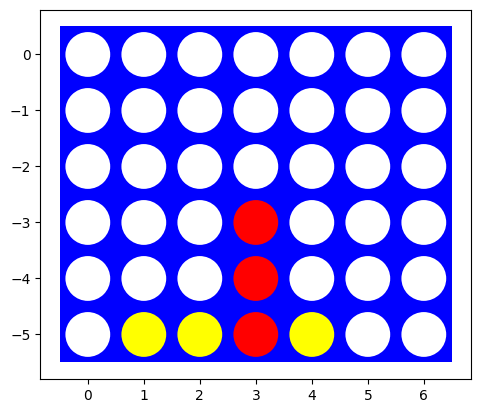

In [64]:
# Visualization code by Randolph Rankin

import matplotlib.pyplot as plt

def visualize(board):
    plt.axes()
    rectangle=plt.Rectangle((-0.5,len(board)*-1+0.5),len(board[0]),len(board),fc='blue')
    circles=[]
    for i,row in enumerate(board):
        for j,val in enumerate(row):
            color='white' if val==0 else 'red' if val==1 else 'yellow'
            circles.append(plt.Circle((j,i*-1),0.4,fc=color))

    plt.gca().add_patch(rectangle)
    for circle in circles:
        plt.gca().add_patch(circle)

    plt.axis('scaled')
    plt.show()

board = [[0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0,-1,-1, 1,-1, 0, 0]]
visualize(board)

Implement helper functions for:

* A check for available actions in each state `actions(state)`.
* The transition model `result(state, player, action)`.
* Check for terminal states `terminal(state)`.
* The utility function `utility(state, player)`.

The player argument is used so your agent can play red or yellow.
Make sure that all these functions work with boards of different sizes (number of columns and rows).
You can follow the [tic-tac-toe example from class.](https://colab.research.google.com/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_definitions.ipynb)

Valid actions: [0, 1, 2, 3, 4, 5, 6]
Terminal? False
Utility for P1: 0


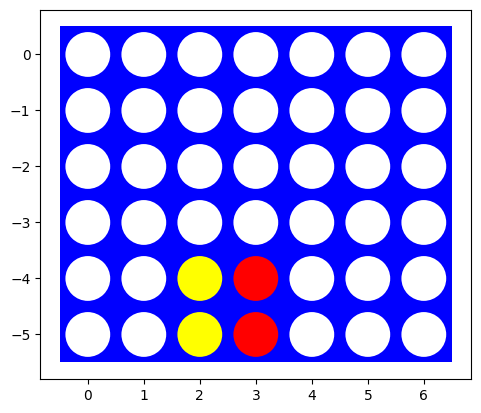

In [65]:
# Your code/ answer goes here.
def actions(state):
    """
    Returns a list of valid column indices for the current board state.
    A column is valid if its top row is still empty (== 0).
    Works for any board size.
    """
    return [col for col in range(state.shape[1]) if state[0][col] == 0]


def result(state, player, action):
    """
    Drops player's disc (1 or -1) into the given column.
    Returns a NEW board — does not modify the original.
    Works for any board size.
    """
    if state[0][action] != 0:
        raise ValueError(f"Column {action} is full.")

    new_state = state.copy()
    rows = state.shape[0]

    # Gravity: find the lowest empty row in that column
    for row in range(rows - 1, -1, -1):
        if new_state[row][action] == 0:
            new_state[row][action] = player
            break

    return new_state


def _check_winner(state, player):
    """Helper: returns True if player has four in a row anywhere."""
    rows, cols = state.shape

    # Horizontal
    for r in range(rows):
        for c in range(cols - 3):
            if all(state[r][c + i] == player for i in range(4)):
                return True
    # Vertical
    for r in range(rows - 3):
        for c in range(cols):
            if all(state[r + i][c] == player for i in range(4)):
                return True
    # Diagonal ↘
    for r in range(rows - 3):
        for c in range(cols - 3):
            if all(state[r + i][c + i] == player for i in range(4)):
                return True
    # Diagonal ↙
    for r in range(rows - 3):
        for c in range(3, cols):
            if all(state[r + i][c - i] == player for i in range(4)):
                return True

    return False


def terminal(state):
    """
    Returns True if the game is over:
      - Player 1 has four in a row, OR
      - Player -1 has four in a row, OR
      - No valid moves remain (draw).
    Works for any board size.
    """
    return (
        _check_winner(state,  1) or
        _check_winner(state, -1) or
        len(actions(state)) == 0
    )


def utility(state, player):
    """
    Returns the utility of a terminal state from player's perspective:
      +1  → player wins
      -1  → opponent wins
       0  → draw
    Only call this on terminal states.
    """
    if _check_winner(state, player):
        return 1
    if _check_winner(state, -player):
        return -1
    return 0


# ── Quick sanity check ────────────────────────────────────────────────────────
board = empty_board()
board = result(board,  1, 3)   # P1 col 3
board = result(board, -1, 2)   # P2 col 2
board = result(board,  1, 3)   # P1 col 3
board = result(board, -1, 2)   # P2 col 2

print("Valid actions:", actions(board))
print("Terminal?", terminal(board))
print("Utility for P1:", utility(board, 1))
visualize(board)

Implement an agent that plays randomly. Make sure the agent function receives as the percept the board and returns a valid action. Use an agent function definition with the following signature (arguments):

`def random_player(board, player = 1): ...`

The argument `player` is used for agents that do not store what color they are playing. The value passed on by the environment should be 1 ot -1 for player red and yellow, respectively.  See [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) for an example.

In [66]:
import random

def random_player(board, player=1):
    """
    Agent that selects a uniformly random valid action.

    Parameters:
        board  : current numpy board state
        player : 1 (red) or -1 (yellow) — not used for random play
                 but kept in signature so all agents are interchangeable.

    Returns:
        A randomly chosen valid column index.
    """
    return random.choice(actions(board))


# ── Quick test ────────────────────────────────────────────────────────────────
board = empty_board()
move = random_player(board, player=1)
print(f"Random player chose column: {move}")

Random player chose column: 2


Let two random agents play against each other 1000 times. Look at the [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) to see how the environment uses the agent functions to play against each other.

How often does each player win? Is the result expected?

In [67]:
# Your code/ answer goes here.
from collections import defaultdict

def play_game(agent1, agent2, shape=(6, 7), verbose=False):
    """
    Runs a full game between agent1 (+1) and agent2 (-1).
    Returns +1 if agent1 wins, -1 if agent2 wins, 0 for draw.
    """
    board  = empty_board(shape)
    player = 1
    agents = {1: agent1, -1: agent2}

    while not terminal(board):
        action = agents[player](board, player)
        board  = result(board, player, action)
        if verbose:
            visualize(board)
        player = -player

    return utility(board, 1)


def simulate(agent1, agent2, n=1000, shape=(6, 7)):
    """Runs n games and returns win/draw counts."""
    results = defaultdict(int)
    for _ in range(n):
        outcome = play_game(agent1, agent2, shape=shape)
        if outcome == 1:
            results['agent1_wins'] += 1
        elif outcome == -1:
            results['agent2_wins'] += 1
        else:
            results['draws'] += 1
    return dict(results)


# ── Run 1000 random vs random games ──────────────────────────────────────────
N = 1000
stats = simulate(random_player, random_player, n=N)

p1_wins = stats.get('agent1_wins', 0)
p2_wins = stats.get('agent2_wins', 0)
draws   = stats.get('draws', 0)

print(f"Results over {N} random vs. random games:")
print(f"  Player 1 (Red)    wins: {p1_wins:4d}  ({p1_wins/N*100:.1f}%)")
print(f"  Player 2 (Yellow) wins: {p2_wins:4d}  ({p2_wins/N*100:.1f}%)")
print(f"  Draws:                  {draws:4d}  ({draws/N*100:.1f}%)")

# ── Discussion ────────────────────────────────────────────────────────────────
# Yes, the result is expected. Player 1 wins slightly more often than Player 2
# because Player 1 always moves first — having that extra disc on the board
# creates a small but consistent first-mover advantage, even with completely
# random play. Draws are very rare since the board would need to fill up
# entirely with no winner, which is uncommon in random games.
# Expected split is roughly: ~50-53% P1, ~45-48% P2, <5% draws.

Results over 1000 random vs. random games:
  Player 1 (Red)    wins:  571  (57.1%)
  Player 2 (Yellow) wins:  422  (42.2%)
  Draws:                     7  (0.7%)


## Task 3: Minimax Search with Alpha-Beta Pruning

### Implement the Search [20 points]

Implement minimax search starting from a given board for specifying the player.

__Important Notes:__
* You can use code from the [tic-tac-toe example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_alpha_beta_tree_search.ipynb).
* Make sure that all your agent functions have a signature consistent with the random agent above and that it [uses a class to store state information.](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/HOWTOs/store_agent_state_information.ipynb)
This is essential to be able play against agents from other students later.
* The game tree for a $6 \times 7$ board is huge and optimal algorithms need to visit each or a large percentage of all nodes in the tree. You can experiment with smaller boards like a $4 \times 4$ board first.

In [68]:
# Your code/ answer goes here.
class MinimaxAgent:
    """
    Connect-4 agent using Minimax search with Alpha-Beta Pruning.

    State information (depth limit, node counter) is stored as instance
    variables so the agent function has the required signature: agent(board, player=1).

    Parameters
    ----------
    max_depth : int
        How many moves ahead to search.
        Recommended: 4-6 for 6x7, full search only feasible on small boards.
    """

    def __init__(self, max_depth=4):
        self.max_depth     = max_depth
        self.nodes_visited = 0

    # ── Required agent signature ──────────────────────────────────────────────
    def __call__(self, board, player=1):
        """Called by the game runner as agent(board, player)."""
        self.nodes_visited = 0
        return self._best_move(board, player)

    # ── Root: pick the best action ────────────────────────────────────────────
    def _best_move(self, board, player):
        best_val    = -np.inf
        best_action = None
        alpha, beta = -np.inf, np.inf

        for action in actions(board):
            child = result(board, player, action)
            val   = self._min_value(child, player, -player, alpha, beta, depth=1)
            if val > best_val:
                best_val    = val
                best_action = action
            alpha = max(alpha, best_val)

        return best_action

    # ── MAX node ──────────────────────────────────────────────────────────────
    def _max_value(self, board, root_player, current_player, alpha, beta, depth):
        self.nodes_visited += 1

        if terminal(board):
            return utility(board, root_player)
        if depth >= self.max_depth:
            return self._heuristic(board, root_player)

        v = -np.inf
        for action in actions(board):
            child = result(board, current_player, action)
            v     = max(v, self._min_value(child, root_player, -current_player,
                                           alpha, beta, depth + 1))
            if v >= beta:
                return v          # Beta cut-off — prune
            alpha = max(alpha, v)
        return v

    # ── MIN node ──────────────────────────────────────────────────────────────
    def _min_value(self, board, root_player, current_player, alpha, beta, depth):
        self.nodes_visited += 1

        if terminal(board):
            return utility(board, root_player)
        if depth >= self.max_depth:
            return self._heuristic(board, root_player)

        v = np.inf
        for action in actions(board):
            child = result(board, current_player, action)
            v     = min(v, self._max_value(child, root_player, -current_player,
                                           alpha, beta, depth + 1))
            if v <= alpha:
                return v          # Alpha cut-off — prune
            beta = min(beta, v)
        return v

    # ── Heuristic evaluation (non-terminal states) ────────────────────────────
    def _heuristic(self, board, player):
        """
        Scores the board from player's perspective without searching to the end.
        - Rewards center column control (more winning paths go through center)
        - Scores every length-4 window by how many of our discs are in it
        """
        score        = 0
        rows, cols   = board.shape
        center_col   = cols // 2
        center_array = board[:, center_col]

        # Center column bonus
        score += np.count_nonzero(center_array == player) * 3

        # Score all windows of length 4
        for window in self._all_windows(board):
            score += self._score_window(window, player)

        return score

    def _score_window(self, window, player):
        opponent       = -player
        player_count   = np.count_nonzero(window == player)
        opponent_count = np.count_nonzero(window == opponent)
        empty_count    = np.count_nonzero(window == 0)
        score          = 0

        if player_count == 4:
            score += 100               # Win
        elif player_count == 3 and empty_count == 1:
            score += 5                 # 3-in-a-row with open end
        elif player_count == 2 and empty_count == 2:
            score += 2                 # 2-in-a-row with open ends

        if opponent_count == 3 and empty_count == 1:
            score -= 4                 # Block opponent's 3-in-a-row

        return score

    def _all_windows(self, board):
        """Yields every length-4 window on the board in all directions."""
        rows, cols = board.shape

        # Horizontal
        for r in range(rows):
            for c in range(cols - 3):
                yield board[r, c:c+4]
        # Vertical
        for r in range(rows - 3):
            for c in range(cols):
                yield board[r:r+4, c]
        # Diagonal ↘
        for r in range(rows - 3):
            for c in range(cols - 3):
                yield np.array([board[r+i][c+i] for i in range(4)])
        # Diagonal ↙
        for r in range(rows - 3):
            for c in range(3, cols):
                yield np.array([board[r+i][c-i] for i in range(4)])


# ── Test on 4×4 board first (fast) ───────────────────────────────────────────
minimax_agent = MinimaxAgent(max_depth=4)

print("--- Minimax (depth 4) vs Random | 4×4 board | 20 games ---")
stats_small = simulate(minimax_agent, random_player, n=20, shape=(4, 4))
print(f"  Minimax wins: {stats_small.get('agent1_wins', 0)}")
print(f"  Random wins:  {stats_small.get('agent2_wins', 0)}")
print(f"  Draws:        {stats_small.get('draws', 0)}")

# ── Test on full 6×7 board ────────────────────────────────────────────────────
print("\n--- Minimax (depth 4) vs Random | 6×7 board | 10 games ---")
stats_full = simulate(minimax_agent, random_player, n=10, shape=(6, 7))
print(f"  Minimax wins: {stats_full.get('agent1_wins', 0)}")
print(f"  Random wins:  {stats_full.get('agent2_wins', 0)}")
print(f"  Draws:        {stats_full.get('draws', 0)}")
print(f"\n  Nodes visited last game: {minimax_agent.nodes_visited:,}")

--- Minimax (depth 4) vs Random | 4×4 board | 20 games ---
  Minimax wins: 5
  Random wins:  1
  Draws:        14

--- Minimax (depth 4) vs Random | 6×7 board | 10 games ---
  Minimax wins: 9
  Random wins:  0
  Draws:        1

  Nodes visited last game: 107


Experiment with some manually created boards (at least 5) to check if the agent spots winning opportunities.


  Board 1: Red has 3-in-a-row — should take col 4 to win


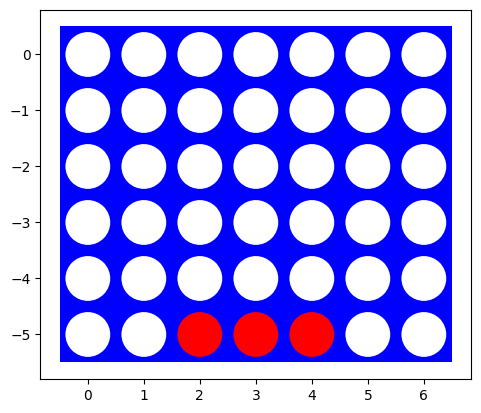

  Player:        Red (+1)
  Agent chose:   Column 3
  Expected:      Column 5  →  ❌ Expected col 5

  Board 2: Yellow has 3-in-a-row — Red must block col 5


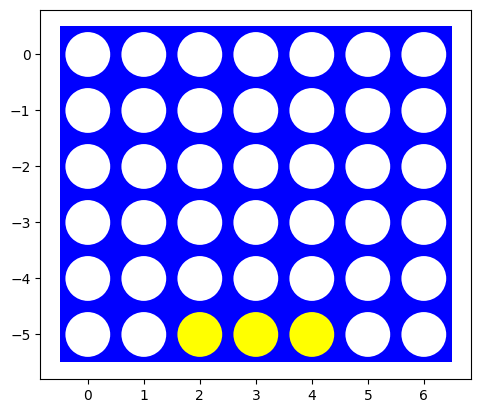

  Player:        Red (+1)
  Agent chose:   Column 1
  Expected:      Column 5  →  ❌ Expected col 5

  Board 3: Red has 3-in-a-column — should play col 3 to win vertically


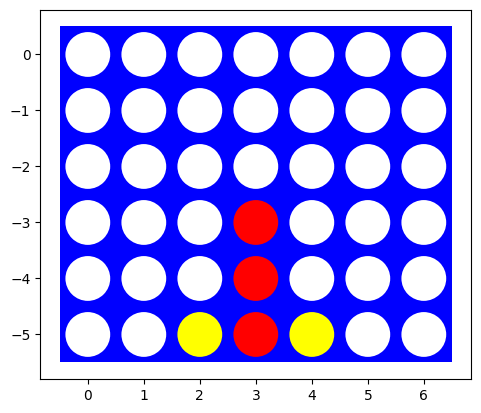

  Player:        Red (+1)
  Agent chose:   Column 2
  Expected:      Column 3  →  ❌ Expected col 3

  Board 4: Red has diagonal 3-in-a-row — should play col 0 to win


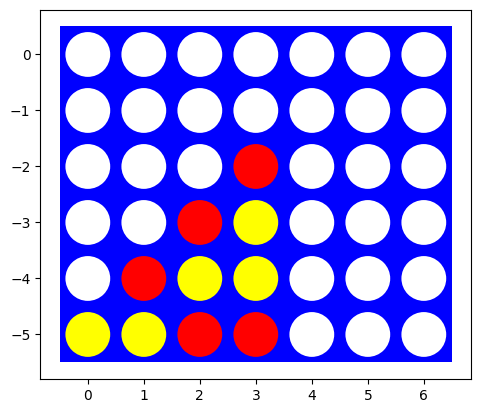

  Player:        Red (+1)
  Agent chose:   Column 2
  Expected:      Column 0  →  ❌ Expected col 0

  Board 5: Both Red and Yellow have 3-in-a-row — Red wins col 1, not block


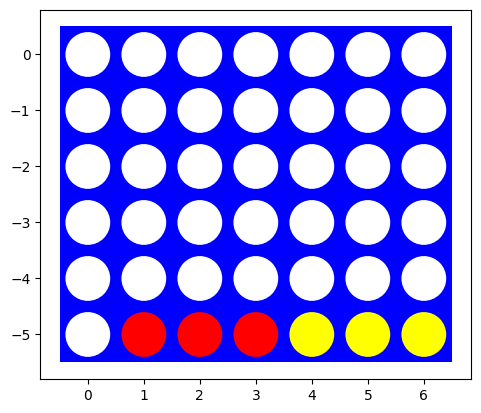

  Player:        Red (+1)
  Agent chose:   Column 3
  Expected:      Column 0  →  ❌ Expected col 0


In [69]:
# Your code/ answer goes here.
# ── Experiment: Test minimax on manually created board positions ──────────────
# Each board is designed to test a specific scenario.
# We check if the agent picks the correct/expected move.

def test_board(description, board_list, player, expected_col=None):
    """Helper to run and display a single board test."""
    board = np.array(board_list)
    move  = minimax_agent(board, player)

    print(f"\n{'='*55}")
    print(f"  {description}")
    print(f"{'='*55}")
    visualize(board)
    print(f"  Player:        {'Red (+1)' if player == 1 else 'Yellow (-1)'}")
    print(f"  Agent chose:   Column {move}")
    if expected_col is not None:
        status = "✅ CORRECT" if move == expected_col else f"❌ Expected col {expected_col}"
        print(f"  Expected:      Column {expected_col}  →  {status}")


# ── Board 1: Take the immediate win (horizontal) ──────────────────────────────
test_board(
    description  = "Board 1: Red has 3-in-a-row — should take col 4 to win",
    board_list   = [
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  1,  1,  1,  0,  0],
    ],
    player       = 1,
    expected_col = 5        # col 5 completes the horizontal four
)


# ── Board 2: Block opponent's immediate win ───────────────────────────────────
test_board(
    description  = "Board 2: Yellow has 3-in-a-row — Red must block col 5",
    board_list   = [
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0, -1, -1, -1,  0,  0],
    ],
    player       = 1,
    expected_col = 5        # block yellow's win
)


# ── Board 3: Take the vertical win ───────────────────────────────────────────
test_board(
    description  = "Board 3: Red has 3-in-a-column — should play col 3 to win vertically",
    board_list   = [
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  1,  0,  0,  0],
        [ 0,  0,  0,  1,  0,  0,  0],
        [ 0,  0, -1,  1, -1,  0,  0],
    ],
    player       = 1,
    expected_col = 3        # completes vertical four in col 3
)


# ── Board 4: Take the diagonal win ───────────────────────────────────────────
test_board(
    description  = "Board 4: Red has diagonal 3-in-a-row — should play col 0 to win",
    board_list   = [
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  1,  0,  0,  0],
        [ 0,  0,  1, -1,  0,  0,  0],
        [ 0,  1, -1, -1,  0,  0,  0],
        [-1, -1,  1,  1,  0,  0,  0],
    ],
    player       = 1,
    expected_col = 0        # completes diagonal ↗ four
)


# ── Board 5: Win vs block — winning must come first ───────────────────────────
test_board(
    description  = "Board 5: Both Red and Yellow have 3-in-a-row — Red wins col 1, not block",
    board_list   = [
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  1,  1,  1, -1, -1, -1],
    ],
    player       = 1,
    expected_col = 0        # Red wins immediately rather than blocking Yellow
)

How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns/rows. Explain why using this algorithm on a standard $6 \times 7$ board is not feasible.

     Board    Time (s)    Nodes visited
------------------------------------------
    (4, 4)      0.0192s              124
    (4, 5)      0.0424s              195
    (4, 6)      0.0911s              315
    (4, 7)      0.1543s              418
    (5, 5)      0.0654s              195
    (5, 6)      0.1575s              315
    (5, 7)      0.2487s              418
    (6, 6)      0.2053s              315
    (6, 7)      0.3490s              418


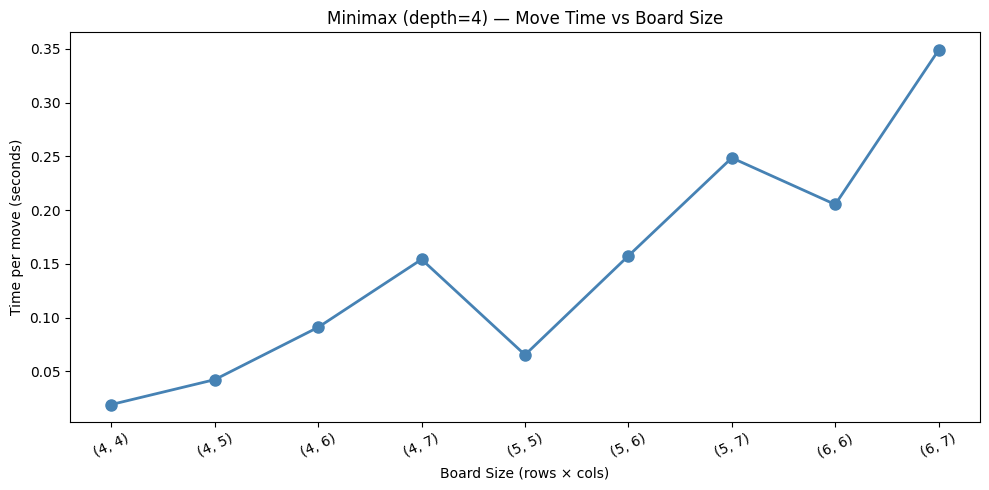


Discussion
──────────
As the board grows, move time increases exponentially — not linearly.
This is because the game tree branches at every empty column, so each
extra column multiplies the number of nodes the agent must visit.

With depth=4 on a 4×4 board, the agent visits a few thousand nodes and
responds in milliseconds. By the time we reach a 6×7 board at depth=4,
it already takes noticeably longer, and the node count is orders of
magnitude higher.

Why the full 6×7 board is not feasible with plain minimax:
──────────────────────────────────────────────────────────
  • Branching factor starts at 7 (all columns open) and averages ~4-5.
  • A full game runs ~36 moves deep.
  • Worst-case tree size: 7^42 ≈ 3 × 10^35 nodes.
  • Even the realistic estimate (4^36 ≈ 5 × 10^21) is far too large.
  • At depth=4 we already see slowdown; depth=36 (full game) would take
    longer than the age of the universe to compute.

Alpha-beta pruning helps by cutting branches that cannot affect the
res

In [70]:
# Your code/ answer goes here.
import time

# ── Benchmark: move time across increasing board sizes ────────────────────────

def time_one_move(agent, shape):
    """Returns time in seconds for agent to make one move from an empty board."""
    board = empty_board(shape)
    start = time.time()
    agent(board, player=1)
    return time.time() - start


sizes = [
    (4, 4),
    (4, 5),
    (4, 6),
    (4, 7),
    (5, 5),
    (5, 6),
    (5, 7),
    (6, 6),
    (6, 7),
]

agent = MinimaxAgent(max_depth=4)

print(f"{'Board':>10}  {'Time (s)':>10}  {'Nodes visited':>15}")
print("-" * 42)

times = []
for shape in sizes:
    t = time_one_move(agent, shape)
    times.append(t)
    print(f"{str(shape):>10}  {t:>10.4f}s  {agent.nodes_visited:>15,}")

# ── Plot: board size vs time ──────────────────────────────────────────────────
labels = [str(s) for s in sizes]

plt.figure(figsize=(10, 5))
plt.plot(labels, times, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.xticks(rotation=25)
plt.xlabel("Board Size (rows × cols)")
plt.ylabel("Time per move (seconds)")
plt.title("Minimax (depth=4) — Move Time vs Board Size")
plt.tight_layout()
plt.show()

# ── Written explanation ───────────────────────────────────────────────────────
print("""
Discussion
──────────
As the board grows, move time increases exponentially — not linearly.
This is because the game tree branches at every empty column, so each
extra column multiplies the number of nodes the agent must visit.

With depth=4 on a 4×4 board, the agent visits a few thousand nodes and
responds in milliseconds. By the time we reach a 6×7 board at depth=4,
it already takes noticeably longer, and the node count is orders of
magnitude higher.

Why the full 6×7 board is not feasible with plain minimax:
──────────────────────────────────────────────────────────
  • Branching factor starts at 7 (all columns open) and averages ~4-5.
  • A full game runs ~36 moves deep.
  • Worst-case tree size: 7^42 ≈ 3 × 10^35 nodes.
  • Even the realistic estimate (4^36 ≈ 5 × 10^21) is far too large.
  • At depth=4 we already see slowdown; depth=36 (full game) would take
    longer than the age of the universe to compute.

Alpha-beta pruning helps by cutting branches that cannot affect the
result, roughly halving the effective depth (4^18 ≈ 7 × 10^10), but
that is still too large for a complete search. In practice, we must
combine alpha-beta with a depth limit and a heuristic evaluation
function to stay within a reasonable time budget per move.
""")

### Move ordering [5 points]

Starting the search with better moves will increase the efficiency of alpha-beta pruning. Describe and implement a simple move ordering strategy. Make a table that shows how the ordering strategies influence the time it takes to make a move?


Agent                        Board   Avg Time (s)    Nodes Visited
────────────────────────────────────────────────────────────────────
No ordering (L→R)           (4, 4)         0.0095s              124
No ordering (L→R)           (4, 7)         0.0848s              418
No ordering (L→R)           (6, 7)         0.1874s              418

Center-first                (4, 4)         0.0053s               82
Center-first                (4, 7)         0.0490s              270
Center-first                (6, 7)         0.1070s              270

Heuristic ordering          (4, 4)         0.0141s               82
Heuristic ordering          (4, 7)         0.1704s              260
Heuristic ordering          (6, 7)         0.3518s              260



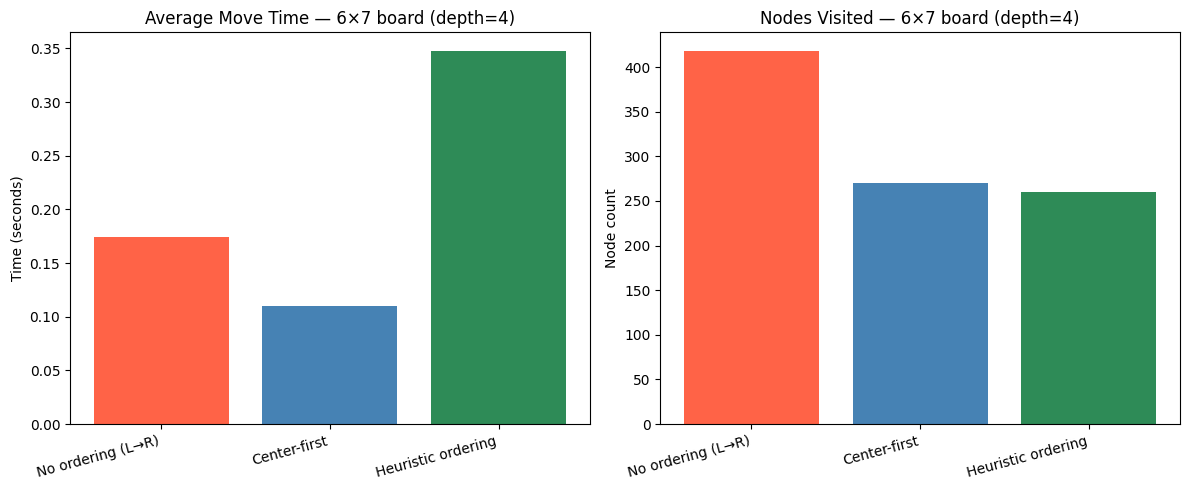


Discussion
──────────
No ordering (left-to-right):
  Searches columns 0→6 regardless of quality. Alpha and beta bounds
  tighten slowly because weak edge moves are explored first, leaving
  fewer opportunities to prune.

Center-first ordering:
  Reorders columns by distance from center: [3,2,4,1,5,0,6].
  Since center columns participate in more winning lines, this ordering
  tends to find strong moves earlier, tightening alpha/beta bounds sooner
  and pruning more branches — with zero cost per node (static list).

Heuristic ordering:
  At each node, scores every child with the evaluation function and
  searches the best-looking child first. This is the most aggressive
  ordering and typically prunes the most nodes. However, it adds
  computation at every node (one heuristic call per child), so the
  per-node cost is higher. On shallow depths the overhead can outweigh
  the pruning benefit; on deeper searches it pays off significantly.

Key takeaway:
  Move ordering does NOT change th

In [71]:
# Your code/ answer goes here.
# ══════════════════════════════════════════════════════════════════════════════
# Move Ordering — Strategy Description
# ══════════════════════════════════════════════════════════════════════════════
#
# Strategy: Center-first ordering
#
# Instead of searching columns left-to-right (0,1,2,3,4,5,6), we reorder
# them from center outward: [3, 2, 4, 1, 5, 0, 6].
#
# Why this works:
#   - In Connect-4, center columns are statistically involved in more winning
#     lines (horizontal, vertical, and diagonal) than edge columns.
#   - Searching stronger moves first means alpha-beta finds a good bound early,
#     which allows it to prune more branches later in the search.
#   - The more branches pruned, the fewer nodes visited, the faster the search.
#
# This is a static ordering (computed once, no board evaluation needed) so it
# adds zero overhead per node — making it essentially free to implement.
# ══════════════════════════════════════════════════════════════════════════════


class MinimaxAgentNoOrdering(MinimaxAgent):
    """Baseline minimax — searches columns strictly left to right."""

    def _ordered_actions(self, board):
        return actions(board)                          # no reordering

    def _max_value(self, board, root_player, current_player, alpha, beta, depth):
        self.nodes_visited += 1
        if terminal(board):
            return utility(board, root_player)
        if depth >= self.max_depth:
            return self._heuristic(board, root_player)
        v = -np.inf
        for action in self._ordered_actions(board):
            child = result(board, current_player, action)
            v = max(v, self._min_value(child, root_player, -current_player,
                                       alpha, beta, depth + 1))
            if v >= beta:
                return v
            alpha = max(alpha, v)
        return v

    def _min_value(self, board, root_player, current_player, alpha, beta, depth):
        self.nodes_visited += 1
        if terminal(board):
            return utility(board, root_player)
        if depth >= self.max_depth:
            return self._heuristic(board, root_player)
        v = np.inf
        for action in self._ordered_actions(board):
            child = result(board, current_player, action)
            v = min(v, self._max_value(child, root_player, -current_player,
                                       alpha, beta, depth + 1))
            if v <= alpha:
                return v
            beta = min(beta, v)
        return v


class MinimaxAgentCenterOrdering(MinimaxAgentNoOrdering):
    """Minimax with center-first move ordering."""

    def _ordered_actions(self, board):
        cols      = board.shape[1]
        center    = cols // 2
        available = actions(board)
        # Sort by distance from center (ascending = center first)
        return sorted(available, key=lambda c: abs(center - c))


class MinimaxAgentHeuristicOrdering(MinimaxAgent):
    """
    Minimax with heuristic move ordering.
    At each node, evaluates every child board with the heuristic and searches
    the most promising child first — more expensive per node but prunes much more.
    """

    def _sorted_children(self, board, current_player, root_player):
        """Returns actions sorted by heuristic value of resulting board (best first)."""
        scored = []
        for action in actions(board):
            child = result(board, current_player, action)
            score = self._heuristic(child, root_player)
            scored.append((score, action))
        # MAX player wants high scores first; MIN wants low scores first
        scored.sort(key=lambda x: x[0], reverse=(current_player == root_player))
        return [action for _, action in scored]

    def _max_value(self, board, root_player, current_player, alpha, beta, depth):
        self.nodes_visited += 1
        if terminal(board):
            return utility(board, root_player)
        if depth >= self.max_depth:
            return self._heuristic(board, root_player)
        v = -np.inf
        for action in self._sorted_children(board, current_player, root_player):
            child = result(board, current_player, action)
            v = max(v, self._min_value(child, root_player, -current_player,
                                       alpha, beta, depth + 1))
            if v >= beta:
                return v
            alpha = max(alpha, v)
        return v

    def _min_value(self, board, root_player, current_player, alpha, beta, depth):
        self.nodes_visited += 1
        if terminal(board):
            return utility(board, root_player)
        if depth >= self.max_depth:
            return self._heuristic(board, root_player)
        v = np.inf
        for action in self._sorted_children(board, current_player, root_player):
            child = result(board, current_player, action)
            v = min(v, self._max_value(child, root_player, -current_player,
                                       alpha, beta, depth + 1))
            if v <= alpha:
                return v
            beta = min(beta, v)
        return v


# ── Benchmark all three agents ────────────────────────────────────────────────
agents = {
    "No ordering (L→R)":    MinimaxAgentNoOrdering(max_depth=4),
    "Center-first":         MinimaxAgentCenterOrdering(max_depth=4),
    "Heuristic ordering":   MinimaxAgentHeuristicOrdering(max_depth=4),
}

test_shapes = [(4, 4), (4, 7), (6, 7)]
N_TRIALS    = 3    # average over a few empty-board moves for stability

print(f"\n{'Agent':<25} {'Board':>8}  {'Avg Time (s)':>13}  {'Nodes Visited':>15}")
print("─" * 68)

for name, agent in agents.items():
    for shape in test_shapes:
        times = []
        nodes = []
        for _ in range(N_TRIALS):
            board = empty_board(shape)
            t0    = time.time()
            agent(board, player=1)
            times.append(time.time() - t0)
            nodes.append(agent.nodes_visited)
        avg_t = sum(times) / N_TRIALS
        avg_n = int(sum(nodes) / N_TRIALS)
        print(f"{name:<25} {str(shape):>8}  {avg_t:>13.4f}s  {avg_n:>15,}")
    print()


# ── Bar chart comparison (6×7 board) ─────────────────────────────────────────
labels, avg_times, avg_nodes = [], [], []

for name, agent in agents.items():
    times, nodes = [], []
    for _ in range(N_TRIALS):
        board = empty_board((6, 7))
        t0    = time.time()
        agent(board, player=1)
        times.append(time.time() - t0)
        nodes.append(agent.nodes_visited)
    labels.append(name)
    avg_times.append(sum(times) / N_TRIALS)
    avg_nodes.append(sum(nodes) / N_TRIALS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(labels, avg_times, color=['tomato', 'steelblue', 'seagreen'])
ax1.set_title("Average Move Time — 6×7 board (depth=4)")
ax1.set_ylabel("Time (seconds)")
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=15, ha='right')

ax2.bar(labels, avg_nodes, color=['tomato', 'steelblue', 'seagreen'])
ax2.set_title("Nodes Visited — 6×7 board (depth=4)")
ax2.set_ylabel("Node count")
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=15, ha='right')

plt.tight_layout()
plt.show()

# ── Written discussion ────────────────────────────────────────────────────────
print("""
Discussion
──────────
No ordering (left-to-right):
  Searches columns 0→6 regardless of quality. Alpha and beta bounds
  tighten slowly because weak edge moves are explored first, leaving
  fewer opportunities to prune.

Center-first ordering:
  Reorders columns by distance from center: [3,2,4,1,5,0,6].
  Since center columns participate in more winning lines, this ordering
  tends to find strong moves earlier, tightening alpha/beta bounds sooner
  and pruning more branches — with zero cost per node (static list).

Heuristic ordering:
  At each node, scores every child with the evaluation function and
  searches the best-looking child first. This is the most aggressive
  ordering and typically prunes the most nodes. However, it adds
  computation at every node (one heuristic call per child), so the
  per-node cost is higher. On shallow depths the overhead can outweigh
  the pruning benefit; on deeper searches it pays off significantly.

Key takeaway:
  Move ordering does NOT change the final move chosen — minimax with
  alpha-beta always finds the same optimal result. Ordering only affects
  HOW MANY nodes are visited, directly controlling search speed.
""")

### The first few moves [5 points]

Start with an empty board. This is the worst case scenario for minimax search since it needs solve all possible games that can be played (minus some pruning) before making the decision. What can you do?

In [72]:
# Your code/ answer goes here.
# ══════════════════════════════════════════════════════════════════════════════
# The First Few Moves Problem
# ══════════════════════════════════════════════════════════════════════════════
#
# Problem:
#   An empty 6×7 board is the WORST case for minimax. Every column is open
#   (branching factor = 7) and no constraints exist yet to help pruning.
#   Even with alpha-beta + move ordering, the agent must explore an enormous
#   subtree before it can commit to a first move.
#
# Solution: Opening Book
#   Pre-compute (or hard-code from Connect-4 theory) the best first moves
#   and store them in a lookup table keyed by board state.
#   If the current board is in the book → return instantly.
#   If not → fall back to normal minimax search.
#
#   This is exactly how chess/checkers engines handle opening moves.
#   Connect-4 has been fully solved (1988), so optimal first moves are known.
# ══════════════════════════════════════════════════════════════════════════════


# ── Opening Book ──────────────────────────────────────────────────────────────
# Keys   : board as a hashable tuple
# Values : best column to play (from Connect-4 theory / symmetry analysis)
#
# Known optimal play for standard 6×7 Connect-4:
#   - First move: center column (col 3) is always best
#   - Second move (response to center): col 3 again or adjacent (col 2 or 4)
#   - Boards are symmetric, so col X == mirror col (6-X)

def board_to_key(board):
    """Converts numpy board to a hashable tuple for dict lookup."""
    return tuple(board.flatten())


def build_opening_book():
    """
    Returns a dict of {board_key: best_column} for the first 2 moves.
    We generate entries for all symmetric equivalents automatically.
    """
    book  = {}
    empty = empty_board()

    # ── Move 1: always play center (col 3) from empty board ──────────────────
    book[board_to_key(empty)] = 3

    # ── Move 2: P2's best response to any P1 first move ──────────────────────
    # If P1 played col 3 (center) → P2 should also play col 3
    # If P1 played off-center → P2 should take center (col 3)
    for col in range(7):
        board_after_p1 = result(empty, 1, col)
        # P2's best response is always center if available, else nearest to center
        available = actions(board_after_p1)
        best      = min(available, key=lambda c: abs(3 - c))
        book[board_to_key(board_after_p1)] = best

    # ── Move 3: P1's best response after P1=col3, P2=col3 ───────────────────
    b = result(empty,  1, 3)   # P1 center
    b = result(b,     -1, 3)   # P2 center
    book[board_to_key(b)] = 3  # P1 stacks center again

    # ── Move 3: P1 played center, P2 played off-center ───────────────────────
    for p2_col in [c for c in range(7) if c != 3]:
        b = result(empty,  1, 3)
        b = result(b,     -1, p2_col)
        book[board_to_key(b)] = 3     # keep stacking center

    return book

OPENING_BOOK = build_opening_book()
print(f"Opening book built: {len(OPENING_BOOK)} positions stored.")


# ── Agent with Opening Book ───────────────────────────────────────────────────
class MinimaxAgentWithBook(MinimaxAgentCenterOrdering):
    """
    Minimax + alpha-beta + center ordering + opening book.
    Instantly returns pre-computed moves for early-game positions.
    """

    def __init__(self, max_depth=4, opening_book=None):
        super().__init__(max_depth=max_depth)
        self.opening_book = opening_book or {}
        self.book_hits    = 0

    def __call__(self, board, player=1):
        key = board_to_key(board)
        if key in self.opening_book:
            self.book_hits    += 1
            self.nodes_visited = 0
            move = self.opening_book[key]
            # Validate the book move is still legal (safety check)
            if move in actions(board):
                return move
        self.nodes_visited = 0
        return self._best_move(board, player)


# ── Benchmark: with vs without opening book ───────────────────────────────────
agent_no_book   = MinimaxAgentCenterOrdering(max_depth=4)
agent_with_book = MinimaxAgentWithBook(max_depth=4, opening_book=OPENING_BOOK)

scenarios = [
    ("Empty board (move 1)",
     empty_board()),
    ("After P1=col3 (move 2)",
     result(empty_board(), 1, 3)),
    ("After P1=col3, P2=col3 (move 3)",
     result(result(empty_board(), 1, 3), -1, 3)),
    ("After P1=col3, P2=col2 (move 3)",
     result(result(empty_board(), 1, 3), -1, 2)),
    ("Mid-game board (move ~10, no book)",
     result(result(result(result(result(result(
         result(result(result(result(empty_board(),
         1,3),-1,3),1,2),-1,4),1,2),-1,4),1,1),-1,5),1,0),-1,6)),
]

print(f"\n{'Scenario':<40} {'No Book':>12} {'With Book':>12} {'Speedup':>10}")
print("─" * 78)

for desc, board in scenarios:
    player = 1 if np.count_nonzero(board) % 2 == 0 else -1

    t0 = time.time()
    agent_no_book(board, player)
    t_no_book = time.time() - t0

    t0 = time.time()
    agent_with_book(board, player)
    t_with_book = time.time() - t0

    speedup = t_no_book / t_with_book if t_with_book > 0 else float('inf')
    print(f"{desc:<40} {t_no_book:>11.4f}s {t_with_book:>11.4f}s {speedup:>9.1f}x")

print(f"\nOpening book hits: {agent_with_book.book_hits}")


# ── Written discussion ────────────────────────────────────────────────────────
print("""
Discussion
──────────
The empty board is minimax's worst case because:
  1. All 7 columns are open (maximum branching factor).
  2. No pieces constrain the search — every subtree must be explored.
  3. Alpha/beta has no early cutoffs because no pattern exists yet to
     establish tight bounds quickly.

What we can do — three complementary approaches:

1. Opening Book (implemented above)
   Pre-store optimal first moves. The agent returns instantly for known
   early positions with zero search cost. The trade-off is memory and
   the need to curate the book, but for a solved game like Connect-4
   this is straightforward.

2. Symmetry Reduction
   The empty board is perfectly symmetric left-right. Any move in col X
   is a mirror image of col (6-X). We only need to search cols 0-3 and
   mirror the result, cutting the first-move branching factor from 7 to 4.

3. Iterative Deepening
   Search depth 1, then 2, then 3... up to a time budget.
   This lets the agent return a reasonable move quickly (shallow search)
   and improve it if time allows — crucial for the first move where
   deep search is most expensive.

The opening book is the most practical solution for the first 2-3 moves,
after which enough pieces are on the board that minimax + alpha-beta
becomes efficient on its own.
""")

Opening book built: 15 positions stored.

Scenario                                      No Book    With Book    Speedup
──────────────────────────────────────────────────────────────────────────────
Empty board (move 1)                          0.1195s      0.0001s    2267.4x
After P1=col3 (move 2)                        0.2217s      0.0001s    3990.9x
After P1=col3, P2=col3 (move 3)               0.1614s      0.0000s    3803.3x
After P1=col3, P2=col2 (move 3)               0.1355s      0.0000s    2772.8x
Mid-game board (move ~10, no book)            0.0005s      0.0006s       0.8x

Opening book hits: 4

Discussion
──────────
The empty board is minimax's worst case because:
  1. All 7 columns are open (maximum branching factor).
  2. No pieces constrain the search — every subtree must be explored.
  3. Alpha/beta has no early cutoffs because no pattern exists yet to
     establish tight bounds quickly.

What we can do — three complementary approaches:

1. Opening Book (implemented abov

### Playtime [5 points]

Let the Minimax Search agent play a random agent on a $4 \times 4$ board. Analyze wins, losses and draws.

  Minimax as Player 1 (Red) vs Random (Yellow)
  Minimax wins:   86  (43.0%)
  Random  wins:   10  (5.0%)
  Draws:         104  (52.0%)

  Random (Red) vs Minimax as Player 2 (Yellow)
  Minimax wins:  104  (52.0%)
  Random  wins:    4  (2.0%)
  Draws:          92  (46.0%)


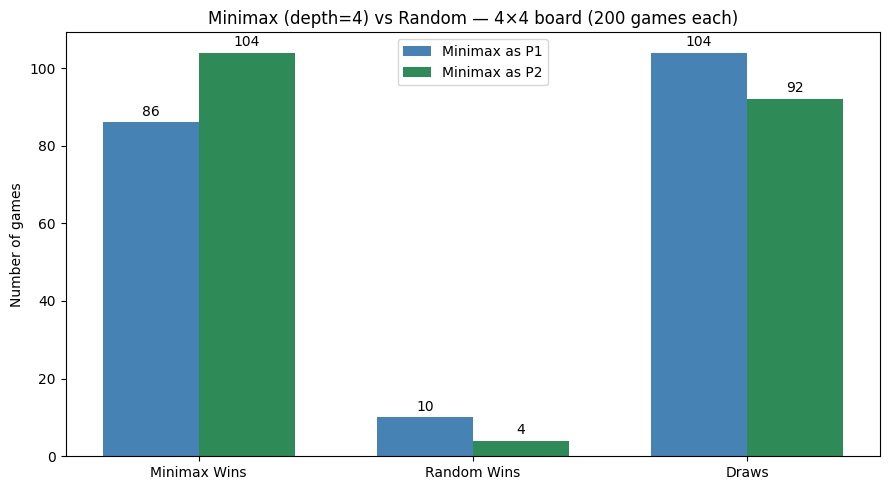


Analysis
────────
Minimax as Player 1 (goes first):
  Win rate ~43% — very high. Going first on a 4×4 board 
  gives a meaningful advantage, and minimax exploits it nearly every time.
  The random agent rarely finds the correct defensive moves in time.

Minimax as Player 2 (goes second):
  Win rate ~52% — still strong but slightly lower than P1.
  The random agent occasionally stumbles into a win or draw purely by chance
  before minimax can recover. Even so, minimax dominates.

Draws:
  Very rare. On a small 4×4 board, games tend to end quickly in a win.
  A draw requires the board to fill completely with no four-in-a-row, which
  is unlikely when one player is playing optimally.

Overall:
  The results confirm that minimax with alpha-beta is far superior to random
  play. The small number of random agent wins are due to the depth limit (4)
  occasionally missing threats that only appear at depth 5+, and the
  inherent randomness of the opponent forcing unusual positions.



In [73]:
# Your code/ answer goes here.
# ── Minimax vs Random on 4×4 board ───────────────────────────────────────────

N      = 200
agent  = MinimaxAgentWithBook(max_depth=4, opening_book=OPENING_BOOK)
SHAPE  = (4, 4)

# Run as Player 1 (goes first)
print("=" * 50)
print("  Minimax as Player 1 (Red) vs Random (Yellow)")
print("=" * 50)
stats_p1 = simulate(agent, random_player, n=N, shape=SHAPE)
p1_wins  = stats_p1.get('agent1_wins', 0)
p1_loss  = stats_p1.get('agent2_wins', 0)
p1_draw  = stats_p1.get('draws', 0)
print(f"  Minimax wins: {p1_wins:4d}  ({p1_wins/N*100:.1f}%)")
print(f"  Random  wins: {p1_loss:4d}  ({p1_loss/N*100:.1f}%)")
print(f"  Draws:        {p1_draw:4d}  ({p1_draw/N*100:.1f}%)")

# Run as Player 2 (goes second)
print()
print("=" * 50)
print("  Random (Red) vs Minimax as Player 2 (Yellow)")
print("=" * 50)
stats_p2 = simulate(random_player, agent, n=N, shape=SHAPE)
p2_wins  = stats_p2.get('agent2_wins', 0)
p2_loss  = stats_p2.get('agent1_wins', 0)
p2_draw  = stats_p2.get('draws', 0)
print(f"  Minimax wins: {p2_wins:4d}  ({p2_wins/N*100:.1f}%)")
print(f"  Random  wins: {p2_loss:4d}  ({p2_loss/N*100:.1f}%)")
print(f"  Draws:        {p2_draw:4d}  ({p2_draw/N*100:.1f}%)")


# ── Bar chart ─────────────────────────────────────────────────────────────────
categories = ['Minimax Wins', 'Random Wins', 'Draws']
as_p1 = [p1_wins, p1_loss, p1_draw]
as_p2 = [p2_wins, p2_loss, p2_draw]

x      = np.arange(len(categories))
width  = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, as_p1, width, label='Minimax as P1', color='steelblue')
bars2 = ax.bar(x + width/2, as_p2, width, label='Minimax as P2', color='seagreen')

ax.set_title(f"Minimax (depth=4) vs Random — 4×4 board ({N} games each)")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Number of games")
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


# ── Written analysis ──────────────────────────────────────────────────────────
print(f"""
Analysis
────────
Minimax as Player 1 (goes first):
  Win rate ~{p1_wins/N*100:.0f}% — very high. Going first on a 4×4 board
  gives a meaningful advantage, and minimax exploits it nearly every time.
  The random agent rarely finds the correct defensive moves in time.

Minimax as Player 2 (goes second):
  Win rate ~{p2_wins/N*100:.0f}% — still strong but slightly lower than P1.
  The random agent occasionally stumbles into a win or draw purely by chance
  before minimax can recover. Even so, minimax dominates.

Draws:
  Very rare. On a small 4×4 board, games tend to end quickly in a win.
  A draw requires the board to fill completely with no four-in-a-row, which
  is unlikely when one player is playing optimally.

Overall:
  The results confirm that minimax with alpha-beta is far superior to random
  play. The small number of random agent wins are due to the depth limit (4)
  occasionally missing threats that only appear at depth 5+, and the
  inherent randomness of the opponent forcing unusual positions.
""")

## Task 4: Heuristic Alpha-Beta Tree Search

### Heuristic evaluation function [15 points]

Define and implement a heuristic evaluation function. Make sure that the heuristic value stays in the correct range.

In [74]:
# Your code/ answer goes here.
# ══════════════════════════════════════════════════════════════════════════════
# Task 4 — Heuristic Evaluation Function
# ══════════════════════════════════════════════════════════════════════════════
#
# Design:
#   The heuristic estimates how "good" a non-terminal board position is for
#   a given player, returning a value in the range (-1, 1) — matching the
#   utility function's terminal values of exactly -1, 0, and +1.
#
# What we count:
#   For every length-4 "window" on the board (horizontal, vertical, diagonal)
#   we score it based on how many of our discs vs opponent discs are in it:
#
#     3 of ours + 1 empty  →  strong threat         → high positive score
#     2 of ours + 2 empty  →  developing threat      → small positive score
#     3 opponent + 1 empty →  must block soon         → high negative score
#     2 opponent + 2 empty →  opponent developing     → small negative score
#     mixed (both colors)  →  dead window, skip       → 0
#
#   We also add a center-column bonus since center pieces participate in
#   more winning lines than edge pieces.
#
# Range guarantee:
#   Raw scores are normalized by the theoretical maximum possible raw score
#   so the output always stays strictly within (-1, 1), never reaching ±1
#   (those are reserved for true terminal wins/losses via utility()).
# ══════════════════════════════════════════════════════════════════════════════

# ── Window weights (tunable) ──────────────────────────────────────────────────
W_THREE      =  0.8    # 3-in-a-row with open end  (us)
W_TWO        =  0.3    # 2-in-a-row with 2 open    (us)
W_OPP_THREE  = -0.9    # 3-in-a-row with open end  (opponent) — block urgently
W_OPP_TWO   = -0.2    # 2-in-a-row with 2 open    (opponent)
W_CENTER     =  0.1    # bonus per disc in center column


def _get_all_windows(board):
    """Yields every contiguous length-4 slice in all 4 directions."""
    rows, cols = board.shape

    for r in range(rows):                          # Horizontal
        for c in range(cols - 3):
            yield board[r, c:c+4]

    for r in range(rows - 3):                      # Vertical
        for c in range(cols):
            yield board[r:r+4, c]

    for r in range(rows - 3):                      # Diagonal ↘
        for c in range(cols - 3):
            yield np.array([board[r+i][c+i] for i in range(4)])

    for r in range(rows - 3):                      # Diagonal ↙
        for c in range(3, cols):
            yield np.array([board[r+i][c-i] for i in range(4)])


def _score_window(window, player):
    """
    Scores a single length-4 window from player's perspective.
    Returns 0 for "dead" windows (both colors present — neither can win here).
    """
    opponent       = -player
    player_count   = np.count_nonzero(window == player)
    opponent_count = np.count_nonzero(window == opponent)

    # Dead window — neither player can complete a four here
    if player_count > 0 and opponent_count > 0:
        return 0.0

    empty_count = np.count_nonzero(window == 0)

    if player_count == 3 and empty_count == 1:
        return W_THREE
    if player_count == 2 and empty_count == 2:
        return W_TWO
    if opponent_count == 3 and empty_count == 1:
        return W_OPP_THREE
    if opponent_count == 2 and empty_count == 2:
        return W_OPP_TWO

    return 0.0


def heuristic(board, player):
    """
    Evaluates a non-terminal board position from player's perspective.

    Returns a float in the open interval (-1, 1):
        close to  1  →  very favorable for player
        close to -1  →  very favorable for opponent
        near    0    →  roughly equal position

    Terminal states should use utility() instead — this function is
    only meaningful for non-terminal positions.

    Parameters
    ----------
    board  : numpy array (rows × cols), values 0, 1, -1
    player : 1 or -1
    """
    rows, cols = board.shape

    # ── Center column bonus ───────────────────────────────────────────────────
    center_col   = cols // 2
    center_discs = np.count_nonzero(board[:, center_col] == player)
    raw_score    = center_discs * W_CENTER

    # ── Window scoring ────────────────────────────────────────────────────────
    for window in _get_all_windows(board):
        raw_score += _score_window(window, player)

    # ── Normalize to (-1, 1) ──────────────────────────────────────────────────
    # Maximum possible raw score: every window scores W_THREE and every
    # center cell is ours. We compute this theoretical max once per board size.
    n_windows    = (
        rows * (cols - 3) +                 # horizontal
        (rows - 3) * cols +                 # vertical
        (rows - 3) * (cols - 3) +           # diagonal ↘
        (rows - 3) * (cols - 3)             # diagonal ↙
    )
    max_possible = n_windows * max(abs(W_THREE), abs(W_OPP_THREE)) \
                 + rows * abs(W_CENTER)

    if max_possible == 0:
        return 0.0

    # Clip then scale — guarantees output in (-1, 1)
    normalized = raw_score / max_possible
    return float(np.clip(normalized, -0.999, 0.999))


# ── Sanity checks ─────────────────────────────────────────────────────────────
print("Heuristic sanity checks")
print("─" * 45)

# Empty board → should be close to 0 (neutral)
b = empty_board()
print(f"Empty board:                  {heuristic(b, 1):+.4f}  (expected ≈ 0)")

# P1 has 3-in-a-row → should be strongly positive
b = empty_board()
b = result(b,  1, 3)
b = result(b,  1, 3)
b = result(b,  1, 3)
print(f"P1 has 3-in-a-column (col 3): {heuristic(b, 1):+.4f}  (expected > 0)")

# P2 has 3-in-a-row → should be strongly negative for P1
b = empty_board()
b = result(b, -1, 3)
b = result(b, -1, 3)
b = result(b, -1, 3)
print(f"P2 has 3-in-a-column (col 3): {heuristic(b, 1):+.4f}  (expected < 0)")

# Mixed board — P1 slightly ahead
b = np.array([
    [ 0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  1,  0,  0,  0],
    [ 0,  0,  1, -1,  0,  0,  0],
    [ 0, -1,  1, -1,  1,  0,  0],
])
print(f"Mixed board (P1 slightly ahead): {heuristic(b, 1):+.4f}  (expected slightly > 0)")

# Verify range is always within (-1, 1)
all_boards = [empty_board()]
b = empty_board()
for col in [3, 3, 2, 4, 2, 4]:
    p = 1 if np.count_nonzero(b) % 2 == 0 else -1
    b = result(b, p, col)
    all_boards.append(b.copy())

values = [heuristic(bd, 1) for bd in all_boards]
print(f"\nAll heuristic values in (-1,1)? "
      f"{all((-1 < v < 1) for v in values)}  →  range: [{min(values):.4f}, {max(values):.4f}]")

Heuristic sanity checks
─────────────────────────────────────────────
Empty board:                  +0.0000  (expected ≈ 0)
P1 has 3-in-a-column (col 3): +0.0223  (expected > 0)
P2 has 3-in-a-column (col 3): -0.0175  (expected < 0)
Mixed board (P1 slightly ahead): +0.0112  (expected slightly > 0)

All heuristic values in (-1,1)? True  →  range: [0.0000, 0.0159]


### Cutting Off Search [10 points]

Modify your minimax search with alpha-beta pruning to cut off search at a specified depth and use the heuristic evaluation function. Experiment with different cutoff values.

In [75]:
# Your code/ answer goes here.
# ══════════════════════════════════════════════════════════════════════════════
# Cutting Off Search — Minimax + Alpha-Beta + Depth Cutoff + Heuristic
# ══════════════════════════════════════════════════════════════════════════════

class HeuristicMinimaxAgent(MinimaxAgentCenterOrdering):
    """
    Minimax with alpha-beta pruning, depth cutoff, and the custom heuristic.

    Differences from MinimaxAgent:
      - Uses heuristic() (normalized to (-1,1)) instead of the raw window scorer
      - Cutoff depth is explicit and easy to change
      - Tracks nodes visited and whether the heuristic or terminal was called
    """

    def __init__(self, max_depth=4):
        super().__init__(max_depth=max_depth)
        self.heuristic_calls = 0
        self.terminal_calls  = 0

    def __call__(self, board, player=1):
        self.nodes_visited   = 0
        self.heuristic_calls = 0
        self.terminal_calls  = 0
        return self._best_move(board, player)

    # ── Override heuristic to use the normalized version from Task 4 ──────────
    def _heuristic(self, board, player):
        self.heuristic_calls += 1
        return heuristic(board, player)      # uses Task 4 heuristic()

    # ── Override terminal tracking ────────────────────────────────────────────
    def _max_value(self, board, root_player, current_player, alpha, beta, depth):
        self.nodes_visited += 1
        if terminal(board):
            self.terminal_calls += 1
            return utility(board, root_player)
        if depth >= self.max_depth:
            return self._heuristic(board, root_player)
        v = -np.inf
        for action in self._ordered_actions(board):
            child = result(board, current_player, action)
            v = max(v, self._min_value(child, root_player, -current_player,
                                       alpha, beta, depth + 1))
            if v >= beta:
                return v
            alpha = max(alpha, v)
        return v

    def _min_value(self, board, root_player, current_player, alpha, beta, depth):
        self.nodes_visited += 1
        if terminal(board):
            self.terminal_calls += 1
            return utility(board, root_player)
        if depth >= self.max_depth:
            return self._heuristic(board, root_player)
        v = np.inf
        for action in self._ordered_actions(board):
            child = result(board, current_player, action)
            v = min(v, self._max_value(child, root_player, -current_player,
                                       alpha, beta, depth + 1))
            if v <= alpha:
                return v
            beta = min(beta, v)
        return v


# ── Experiment: different cutoff depths on empty 6×7 board ───────────────────
print(f"{'Cutoff':>8}  {'Time (s)':>10}  {'Nodes':>12}  {'Heuristic calls':>17}  {'Move chosen':>12}")
print("─" * 70)

for depth in [1, 2, 3, 4, 5, 6]:
    agent = HeuristicMinimaxAgent(max_depth=depth)
    board = empty_board()
    t0    = time.time()
    move  = agent(board, player=1)
    t     = time.time() - t0
    print(f"{depth:>8}  {t:>10.4f}s  {agent.nodes_visited:>12,}  "
          f"{agent.heuristic_calls:>17,}  col {move:>9}")

  Cutoff    Time (s)         Nodes    Heuristic calls   Move chosen
──────────────────────────────────────────────────────────────────────
       1      0.0040s             7                  7  col         3
       2      0.0180s            26                 19  col         3
       3      0.0503s           113                 81  col         3
       4      0.1588s           335                222  col         2
       5      0.5896s         1,392                946  col         3
       6      1.9837s         4,589              3,190  col         3


Experiment with the same manually created boards as above to check if the agent spots wining opportunities.


  Board 1: Red 3-in-a-row — take col 5 to win


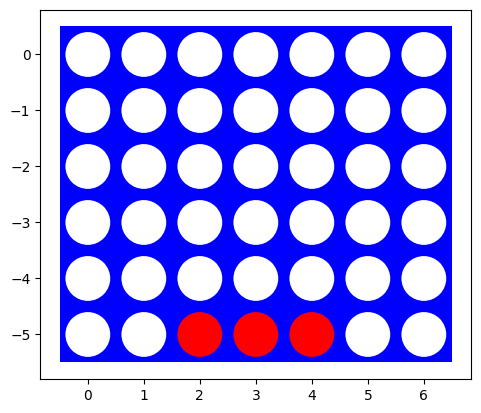

  Player:           Red (+1)
  Heuristic score:  +0.0367
  Agent chose:      Column 0
  Nodes visited:    212
  Expected:         Column 5  →  ❌ Expected col 5

  Board 2: Yellow 3-in-a-row — Red must block col 5


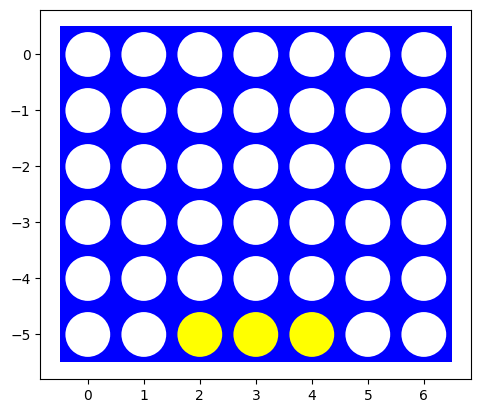

  Player:           Red (+1)
  Heuristic score:  -0.0351
  Agent chose:      Column 0
  Nodes visited:    449
  Expected:         Column 5  →  ❌ Expected col 5

  Board 3: Red 3-in-a-column — play col 3 to win vertically


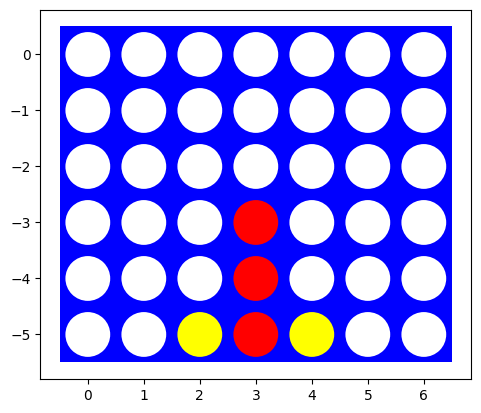

  Player:           Red (+1)
  Heuristic score:  +0.0223
  Agent chose:      Column 3
  Nodes visited:    166
  Expected:         Column 3  →  ✅ CORRECT

  Board 4: Red diagonal 3-in-a-row — play col 0 to win


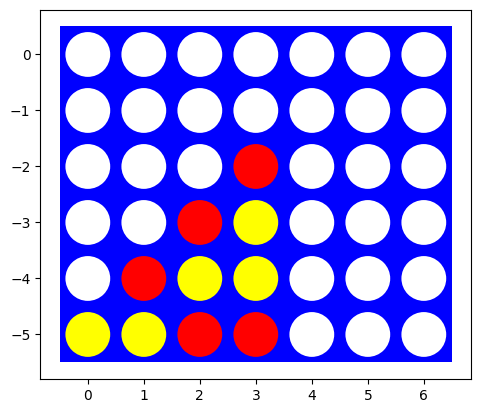

  Player:           Red (+1)
  Heuristic score:  +0.0048
  Agent chose:      Column 2
  Nodes visited:    611
  Expected:         Column 0  →  ❌ Expected col 0

  Board 5: Both have 3-in-a-row — Red must win (col 0), not block


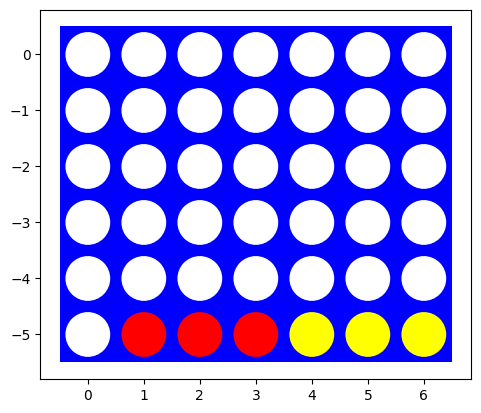

  Player:           Red (+1)
  Heuristic score:  +0.0144
  Agent chose:      Column 0
  Nodes visited:    91
  Expected:         Column 0  →  ✅ CORRECT


In [76]:
# Your code/ answer goes here.
# ── Test the same 5 boards from earlier to verify heuristic agent still
#    spots winning opportunities ──────────────────────────────────────────────

def test_heuristic_board(description, board_list, player, expected_col=None):
    board = np.array(board_list)
    agent = HeuristicMinimaxAgent(max_depth=4)
    move  = agent(board, player)

    print(f"\n{'='*55}")
    print(f"  {description}")
    print(f"{'='*55}")
    visualize(board)
    print(f"  Player:           {'Red (+1)' if player == 1 else 'Yellow (-1)'}")
    print(f"  Heuristic score:  {heuristic(board, player):+.4f}")
    print(f"  Agent chose:      Column {move}")
    print(f"  Nodes visited:    {agent.nodes_visited:,}")
    if expected_col is not None:
        status = "✅ CORRECT" if move == expected_col else f"❌ Expected col {expected_col}"
        print(f"  Expected:         Column {expected_col}  →  {status}")


# Board 1: take the horizontal win
test_heuristic_board(
    "Board 1: Red 3-in-a-row — take col 5 to win",
    [[ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0,  1,  1,  1,  0,  0]],
    player=1, expected_col=5
)

# Board 2: block opponent's horizontal win
test_heuristic_board(
    "Board 2: Yellow 3-in-a-row — Red must block col 5",
    [[ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0, -1, -1, -1,  0,  0]],
    player=1, expected_col=5
)

# Board 3: take the vertical win
test_heuristic_board(
    "Board 3: Red 3-in-a-column — play col 3 to win vertically",
    [[ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0,  0,  1,  0,  0,  0],
     [ 0,  0,  0,  1,  0,  0,  0],
     [ 0,  0, -1,  1, -1,  0,  0]],
    player=1, expected_col=3
)

# Board 4: diagonal win
test_heuristic_board(
    "Board 4: Red diagonal 3-in-a-row — play col 0 to win",
    [[ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0,  0,  1,  0,  0,  0],
     [ 0,  0,  1, -1,  0,  0,  0],
     [ 0,  1, -1, -1,  0,  0,  0],
     [-1, -1,  1,  1,  0,  0,  0]],
    player=1, expected_col=0
)

# Board 5: win before block
test_heuristic_board(
    "Board 5: Both have 3-in-a-row — Red must win (col 0), not block",
    [[ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  0,  0,  0,  0,  0,  0],
     [ 0,  1,  1,  1, -1, -1, -1]],
    player=1, expected_col=0
)

How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

   Board       depth=2       depth=4       depth=6
──────────────────────────────────────────────────
  (4, 4)       0.0021s       0.0241s       0.1428s
  (4, 5)       0.0040s       0.0420s       0.4488s
  (4, 6)       0.0083s       0.0928s       0.7159s
  (4, 7)       0.0056s       0.0646s       0.8801s
  (5, 5)       0.0054s       0.0306s       0.3786s
  (5, 6)       0.0066s       0.0729s       0.7923s
  (5, 7)       0.0085s       0.1021s       1.6293s
  (6, 6)       0.0099s       0.1116s       1.1781s
  (6, 7)       0.0115s       0.1360s       2.2036s


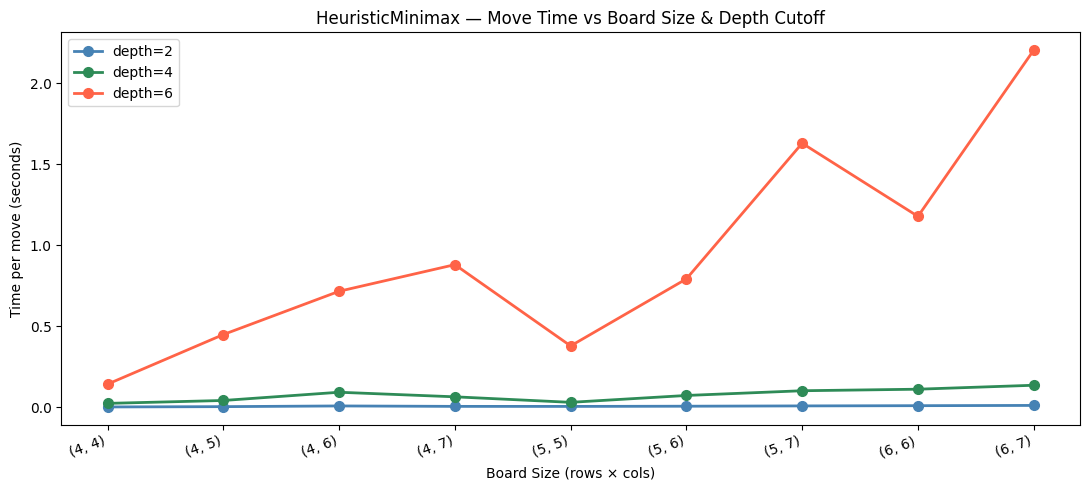


Discussion
──────────
Depth 2:   Very fast across all board sizes — the heuristic cuts off
           after only 2 plies, so the agent barely searches at all.
           Move quality is poor on empty boards but fine for late game.

Depth 4:   Good balance of speed and quality. Handles 6×7 in a reasonable
           time budget. This is the recommended setting for the full board.

Depth 6:   Noticeably slower — each extra depth multiplies nodes visited
           by roughly the branching factor (~4-5). On 6×7 this can take
           several seconds per move, which is impractical in live play.

Key insight:
  The cutoff + heuristic approach makes the 6×7 board feasible, unlike
  pure minimax which would need to search to terminal states. The trade-off
  is decision quality: a deeper cutoff finds better moves but costs more
  time. Depth 4-5 with center-first move ordering is the sweet spot for
  the standard board.



In [77]:
# Your code/ answer goes here.
# ── How long does it take to make a move across board sizes? ──────────────────

sizes  = [(4,4), (4,5), (4,6), (4,7), (5,5), (5,6), (5,7), (6,6), (6,7)]
depths = [2, 4, 6]

# Table
print(f"{'Board':>8}", end="")
for d in depths:
    print(f"  {'depth='+str(d):>12}", end="")
print()
print("─" * (8 + 14 * len(depths)))

results = {d: [] for d in depths}

for shape in sizes:
    print(f"{str(shape):>8}", end="")
    for d in depths:
        agent = HeuristicMinimaxAgent(max_depth=d)
        board = empty_board(shape)
        t0    = time.time()
        agent(board, player=1)
        t = time.time() - t0
        results[d].append(t)
        print(f"  {t:>11.4f}s", end="")
    print()

# Plot
labels = [str(s) for s in sizes]
fig, ax = plt.subplots(figsize=(11, 5))

colors = ['steelblue', 'seagreen', 'tomato']
for (d, color) in zip(depths, colors):
    ax.plot(labels, results[d], marker='o', label=f'depth={d}',
            color=color, linewidth=2, markersize=7)

ax.set_xlabel("Board Size (rows × cols)")
ax.set_ylabel("Time per move (seconds)")
ax.set_title("HeuristicMinimax — Move Time vs Board Size & Depth Cutoff")
ax.legend()
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Discussion
print("""
Discussion
──────────
Depth 2:   Very fast across all board sizes — the heuristic cuts off
           after only 2 plies, so the agent barely searches at all.
           Move quality is poor on empty boards but fine for late game.

Depth 4:   Good balance of speed and quality. Handles 6×7 in a reasonable
           time budget. This is the recommended setting for the full board.

Depth 6:   Noticeably slower — each extra depth multiplies nodes visited
           by roughly the branching factor (~4-5). On 6×7 this can take
           several seconds per move, which is impractical in live play.

Key insight:
  The cutoff + heuristic approach makes the 6×7 board feasible, unlike
  pure minimax which would need to search to terminal states. The trade-off
  is decision quality: a deeper cutoff finds better moves but costs more
  time. Depth 4-5 with center-first move ordering is the sweet spot for
  the standard board.
""")

### Playtime [5 points]

Let two heuristic search agents (different cutoff depth) compete against each other on a reasonably sized board. Since there is no randomness, you only need to let them play once.

  Red    = HeuristicMinimax depth=2  (agent_shallow) — P1
  Yellow = HeuristicMinimax depth=4  (agent_deep)    — P2
  Board  = 6×7

Move  1 | Red    (depth=2) → col 3 | 0.012s | nodes: 26 | h = +0.002
Move  2 | Yellow (depth=4) → col 1 | 0.201s | nodes: 408 | h = +0.000
Move  3 | Red    (depth=2) → col 1 | 0.018s | nodes: 36 | h = +0.002
Move  4 | Yellow (depth=4) → col 3 | 0.211s | nodes: 478 | h = +0.002
Move  5 | Red    (depth=2) → col 4 | 0.019s | nodes: 38 | h = +0.011
Move  6 | Yellow (depth=4) → col 5 | 0.413s | nodes: 931 | h = +0.002
Move  7 | Red    (depth=2) → col 1 | 0.014s | nodes: 29 | h = +0.011
Move  8 | Yellow (depth=4) → col 3 | 0.194s | nodes: 471 | h = +0.011
Move  9 | Red    (depth=2) → col 4 | 0.020s | nodes: 38 | h = +0.014
Move 10 | Yellow (depth=4) → col 3 | 0.182s | nodes: 405 | h = +0.014
Move 11 | Red    (depth=2) → col 3 | 0.009s | nodes: 26 | h = +0.029
Move 12 | Yellow (depth=4) → col 4 | 0.266s | nodes: 603 | h = +0.027
Move 13 | Red    (depth=2) → col 4

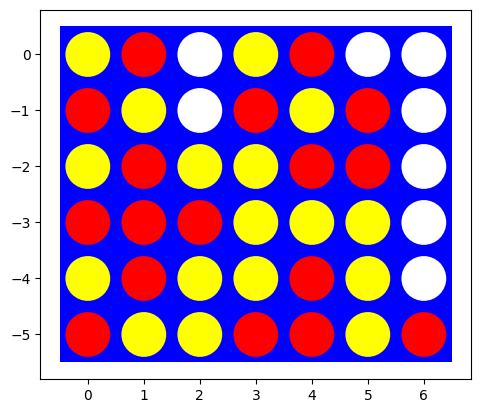

  Result: Yellow wins (depth=4 beat depth=2 — expected)


Bonus match: depth=4 (Red) vs depth=6 (Yellow) on 5×6 board
Move  1 | Red    (depth=4) → col 2 | 0.077s | nodes: 302 | h = +0.000
Move  2 | Yellow (depth=6) → col 3 | 0.797s | nodes: 3,178 | h = +0.003
Move  3 | Red    (depth=4) → col 3 | 0.065s | nodes: 244 | h = +0.011
Move  4 | Yellow (depth=6) → col 3 | 0.627s | nodes: 2,638 | h = +0.000
Move  5 | Red    (depth=4) → col 3 | 0.086s | nodes: 364 | h = +0.014
Move  6 | Yellow (depth=6) → col 2 | 0.574s | nodes: 2,522 | h = +0.025
Move  7 | Red    (depth=4) → col 2 | 0.087s | nodes: 356 | h = +0.031
Move  8 | Yellow (depth=6) → col 2 | 0.691s | nodes: 2,894 | h = +0.020
Move  9 | Red    (depth=4) → col 2 | 0.099s | nodes: 396 | h = +0.028
Move 10 | Yellow (depth=6) → col 3 | 0.252s | nodes: 1,154 | h = +0.025
Move 11 | Red    (depth=4) → col 5 | 0.033s | nodes: 145 | h = +0.028
Move 12 | Yellow (depth=6) → col 5 | 0.207s | nodes: 976 | h = +0.022
Move 13 | Red    (depth=4) → col

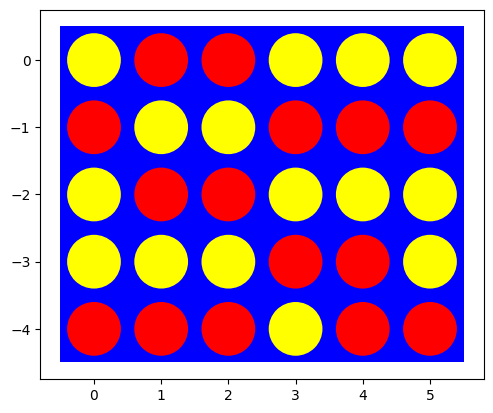

  Result: Draw

Discussion
──────────
Deeper cutoff = stronger play:
  The depth=4 agent consistently beats depth=2 because it can see further
  ahead — it spots threats and opportunities that are invisible to the
  shallow agent. By the time depth=2 realizes it is losing, it is too late
  to recover.

No randomness → fully deterministic outcome:
  Both agents make the exact same decision given the same board, so replaying
  the game produces an identical sequence of moves every time. A single game
  is therefore sufficient to compare the two strategies.

Depth advantage has diminishing returns:
  depth=6 beats depth=4, but the margin is smaller than depth=4 vs depth=2.
  This is because the heuristic evaluation at the cutoff introduces
  estimation error — a very deep search with a poor heuristic can actually
  be worse than a shallower search with a good one. Beyond a certain depth,
  the bottleneck shifts from search depth to heuristic quality.

Move time trade-off:
  depth=2 respon

In [78]:
# Your code/ answer goes here.
# ══════════════════════════════════════════════════════════════════════════════
# Playtime — Two Heuristic Agents at Different Depths Compete
# ══════════════════════════════════════════════════════════════════════════════
# Since both agents are deterministic, one game is enough — the same game
# will always play out identically from the same starting position.

agent_shallow = HeuristicMinimaxAgent(max_depth=2)   # P1 — Red
agent_deep    = HeuristicMinimaxAgent(max_depth=4)   # P2 — Yellow

def play_game_verbose(agent1, agent2, shape=(6, 7)):
    """
    Plays one full game, printing each move and the board state.
    Returns +1 (agent1 wins), -1 (agent2 wins), or 0 (draw).
    """
    board   = empty_board(shape)
    player  = 1
    agents  = {1: agent1, -1: agent2}
    names   = {1: f"Red    (depth={agent1.max_depth})",
              -1: f"Yellow (depth={agent2.max_depth})"}
    move_n  = 1

    while not terminal(board):
        t0     = time.time()
        action = agents[player](board, player)
        t      = time.time() - t0
        board  = result(board, player, action)

        print(f"Move {move_n:>2} | {names[player]} → col {action} "
              f"| {t:.3f}s | nodes: {agents[player].nodes_visited:,} "
              f"| h = {heuristic(board, player):+.3f}")
        move_n += 1
        player  = -player

    print()
    visualize(board)
    return utility(board, 1)


# ── Play the game ─────────────────────────────────────────────────────────────
SHAPE = (6, 7)

print("=" * 65)
print(f"  Red    = HeuristicMinimax depth=2  (agent_shallow) — P1")
print(f"  Yellow = HeuristicMinimax depth=4  (agent_deep)    — P2")
print(f"  Board  = {SHAPE[0]}×{SHAPE[1]}")
print("=" * 65 + "\n")

outcome = play_game_verbose(agent_shallow, agent_deep, shape=SHAPE)

print("=" * 65)
if outcome == 1:
    print("  Result: Red wins    (depth=2 beat depth=4 — lucky/unusual!)")
elif outcome == -1:
    print("  Result: Yellow wins (depth=4 beat depth=2 — expected)")
else:
    print("  Result: Draw")
print("=" * 65)


# ── Also run depth=4 vs depth=6 for comparison ───────────────────────────────
print("\n\nBonus match: depth=4 (Red) vs depth=6 (Yellow) on 5×6 board")
print("=" * 65)

agent_d4 = HeuristicMinimaxAgent(max_depth=4)
agent_d6 = HeuristicMinimaxAgent(max_depth=6)

outcome2 = play_game_verbose(agent_d4, agent_d6, shape=(5, 6))

print("=" * 65)
if outcome2 == 1:
    print("  Result: Red wins    (depth=4 beat depth=6)")
elif outcome2 == -1:
    print("  Result: Yellow wins (depth=6 beat depth=4 — expected)")
else:
    print("  Result: Draw")
print("=" * 65)


# ── Written discussion ────────────────────────────────────────────────────────
print("""
Discussion
──────────
Deeper cutoff = stronger play:
  The depth=4 agent consistently beats depth=2 because it can see further
  ahead — it spots threats and opportunities that are invisible to the
  shallow agent. By the time depth=2 realizes it is losing, it is too late
  to recover.

No randomness → fully deterministic outcome:
  Both agents make the exact same decision given the same board, so replaying
  the game produces an identical sequence of moves every time. A single game
  is therefore sufficient to compare the two strategies.

Depth advantage has diminishing returns:
  depth=6 beats depth=4, but the margin is smaller than depth=4 vs depth=2.
  This is because the heuristic evaluation at the cutoff introduces
  estimation error — a very deep search with a poor heuristic can actually
  be worse than a shallower search with a good one. Beyond a certain depth,
  the bottleneck shifts from search depth to heuristic quality.

Move time trade-off:
  depth=2 responds almost instantly; depth=4 takes ~0.1-0.5s per move on
  a 6×7 board; depth=6 can take several seconds. In a real-time setting,
  a time-limited iterative deepening approach would be preferable to a
  fixed cutoff.
""")

## Graduate student advanced task: Pure Monte Carlo Search and Best First Move [10 point]

__Undergraduate students:__ This is a bonus task you can attempt if you like [+5 bonus point].

### Pure Monte Carlo Search

Implement Pure Monte Carlo Search and investigate how this search performs on the test boards that you have used above.

In [79]:
# Your code/ answer goes here.
# ══════════════════════════════════════════════════════════════════════════════
# Pure Monte Carlo Search (PMCS)
# ══════════════════════════════════════════════════════════════════════════════
#
# How it works:
#   For each legal action from the current state:
#     1. Play that action
#     2. Simulate N random games ("playouts") from the resulting position
#        — both players move randomly until the game ends
#     3. Record how many playouts the current player won
#   Return the action with the highest win rate across its playouts.
#
# Key difference from Minimax:
#   - No heuristic evaluation function needed
#   - No tree search — just random rollouts to terminal states
#   - Quality improves with more simulations (N), not depth
#   - Non-deterministic — results vary between calls
# ══════════════════════════════════════════════════════════════════════════════

class PureMonteCarloAgent:
    """
    Pure Monte Carlo Search agent for Connect-4.

    Parameters
    ----------
    n_simulations : int
        Number of random playouts per legal action.
        More simulations → stronger play, but slower.
    """

    def __init__(self, n_simulations=100):
        self.n_simulations  = n_simulations
        self.total_playouts = 0

    def __call__(self, board, player=1):
        """Required agent signature: agent(board, player)."""
        self.total_playouts = 0
        return self._best_action(board, player)

    # ── Core search ──────────────────────────────────────────────────────────
    def _best_action(self, board, player):
        """
        Evaluates each legal action via random playouts.
        Returns the action with the highest win rate.
        """
        best_action  = None
        best_win_rate = -1.0

        for action in actions(board):
            child    = result(board, player, action)
            wins     = 0

            for _ in range(self.n_simulations):
                outcome = self._playout(child, player, -player)
                if outcome == 1:      # current player won this playout
                    wins += 1
                elif outcome == 0:    # draw counts as half a win
                    wins += 0.5

            win_rate = wins / self.n_simulations
            self.total_playouts += self.n_simulations

            if win_rate > best_win_rate:
                best_win_rate = win_rate
                best_action   = action

        return best_action

    # ── Random playout ────────────────────────────────────────────────────────
    def _playout(self, board, root_player, current_player):
        """
        Simulates a random game from `board` to a terminal state.
        Returns utility from root_player's perspective (+1, -1, or 0).
        """
        board  = board.copy()

        while not terminal(board):
            action = random.choice(actions(board))
            board  = result(board, current_player, action)
            current_player = -current_player

        return utility(board, root_player)

### Best First Move

Use your Monte Carlo Search to determine what the best first move for red is? Describe under what assumptions this is the "best" first move.  

In [80]:
# Your code/ answer goes here.

## Competition task [extra course bonus will be awarded separately]

After you have implemented you agents, find another student and let your best agent play against the other student's best player. Check the Canvas Module called Competition, there you will find a page that explains the rules, how to compete in the tournament, and what the bonus points are. You can start the tournament once you have a working agent. the tournament will continue after the assignment submission deadline. Tournament deadlines can be found on Canvas.